# 01 — Data Audit

Before any visualization or modeling, this notebook asks one question: can we trust this data? We look at structure, missing values, class balance, and potential leakage risks before touching anything else.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [3]:
# column names are from data source, check data_card.md
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

In [4]:
# upload data into pandas dataframes
train = pd.read_csv(
    "../data/raw/adult.data",
    names=columns,
    skipinitialspace=True
)

test = pd.read_csv(
    "../data/raw/adult.test",
    names=columns,
    skipinitialspace=True,
    skiprows=1
)

In [5]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (32561, 15)
Test shape:  (16281, 15)


## 2. Basic Structure

In [6]:
train.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [7]:
train.dtypes

age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

In [8]:
train.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Observations 1 - Basic Structure

- **age:** ranges from 17 to 90, no obvious outliers. Mean app. 38
- **fnlwgt:** census sampling weight with very high variance, 12K to 1.48M.
    This column will be dropped before modeling. It reflects how the census was collected, not individual characteristics.
- **education-num:** ranges 1 - 16, mean ~10. Numerical encoding of education level - redundant with the education column. It should be examined, and one will be dropped.
- **capital-gain:** mean ~1077 but 75th percentile is 0. Max is 99,999, likely a cap value, not a real observation. Heavily zero-inflated. Need log transformation or special treatment.
- **capital-loss:** same pattern, 75th percentile is 0, heavily zero-inflated.
- **hours-per-week:** ranges 1 to 99. Mean ~40 as expected. Max of 99 is suspicious. It could be a cap or data entry artifact.

In [9]:
train.income.value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

### Observations 2 - Class Balance

~75% of instances are <=50K, ~25% are >50K. This imbalance is meaningful a naive model predicting <=50K for everyone would achieve 75% accuracy. Accuracy alone is therefore a misleading metric for this dataset. Precision-recall curves and F1 score will be more informative than ROC-AUC alone.

_____________________________________

## 3. Missing Values

Missing values in this dataset are encoded as `?` — not standard nulls.
A naive `df.isnull().sum()` would return zero and give false confidence.

In [10]:
# standard null check -- will show nothing
print("Standard null check:")
print(train.isnull().sum())

Standard null check:
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [11]:
# actual missing values encoded as "?"
print("Actual missing values (encoded as '?'):")
missing = (train == "?").sum()
print(missing[missing > 0])
print()
print("As percentage of total rows:")
print((missing[missing > 0] / len(train) * 100).round(2))

Actual missing values (encoded as '?'):
workclass         1836
occupation        1843
native-country     583
dtype: int64

As percentage of total rows:
workclass         5.64
occupation        5.66
native-country    1.79
dtype: float64


### Observations 3 — Missing Values

Standard `isnull()` returns zero — missing values are encoded as `?` and require explicit detection.

Three columns contain missing values:
- **workclass:** 1,836 missing (5.64%) 
- **occupation:** 1,843 missing (5.66%) 
- **native-country:** 583 missing (1.79%)

The near-identical counts in `workclass` and `occupation` are not coincidental — they are likely the same rows. Someone without a recorded 
workclass probably also has no recorded occupation. This needs verification. As you see, this is exploration step, we cannot be sure unless we examined in detail.

In [12]:
# are workclass and occupation missing in the same rows?
both_missing = ((train["workclass"] == "?") & (train["occupation"] == "?")).sum()
print(f"Rows where both workclass AND occupation are missing: {both_missing}")

Rows where both workclass AND occupation are missing: 1836


The 7 rows where `occupation` is missing but `workclass` is not are an 
edge case worth investigating separately.

This means we are not dealing with random missingness.
People who are unemployed, retired, or outside the formal economy may systematically lack both fields. 
Imputing these blindly would introduce bias.

**Strategy:** create a `missing` category for both columns rather than imputing because the absence of information is itself informative.

In [13]:
# rows where occupation is missing but workclass is not
edge_cases = train[(train["occupation"] == "?") & (train["workclass"] != "?")]
print(edge_cases["workclass"].value_counts())

workclass
Never-worked    7
Name: count, dtype: int64


In [14]:
print(train.workclass.value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


In [15]:
print(train.occupation.value_counts())

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64


### Observation 4 — Never-worked Edge Case

The 7 rows where `occupation` is missing and `workclass` is all labeled `Never-worked`. This makes complete sense — someone who has never worked has no occupation to report. This is not a data quality issue, it is a logically consistent pattern.

This confirms our strategy: treat `?` as a meaningful category called `Unknown` rather than imputing. For `Never-worked` rows, occupation 
will be set to `Never-worked` to maintain consistency.

### Check test set

In [16]:
print("Missing values in test set:")
missing_test = (test == "?").sum()
print(missing_test[missing_test > 0])
print()
print("As percentage of total rows:")
print((missing_test[missing_test > 0] / len(test) * 100).round(2))

Missing values in test set:
workclass         963
occupation        966
native-country    274
dtype: int64

As percentage of total rows:
workclass         5.91
occupation        5.93
native-country    1.68
dtype: float64


### Observation 5 — Missing Pattern Consistent Across Train and Test

Test set shows the same structural missing pattern:
- **workclass:** 5.91% missing (train: 5.64%)
- **occupation:** 5.93% missing (train: 5.66%)
- **native-country:** 1.68% missing (train: 1.79%)

Proportions are stable across splits — this is not a sampling artifact.
The missingness is a consistent property of the data collection process, further supporting the decision to treat `?` as a meaningful category rather than imputing.

## 4. Leakage and Proxy Risk

Some features may act as proxies for protected attributes, not leakage in the traditional sense, but a fairness risk. 
We identify these before modeling.

In [18]:
# occupation distribution by sex -- proxy risk check
print(train.groupby("sex")["occupation"].value_counts(normalize=True))

sex     occupation       
Female  Adm-clerical         2537
        Other-service        1800
        Prof-specialty       1515
        Sales                1263
        Exec-managerial      1159
        ?                     841
        Machine-op-inspct     550
        Tech-support          348
        Craft-repair          222
        Handlers-cleaners     164
        Priv-house-serv       141
        Transport-moving       90
        Protective-serv        76
        Farming-fishing        65
Male    Craft-repair         3877
        Exec-managerial      2907
        Prof-specialty       2625
        Sales                2387
        Transport-moving     1507
        Other-service        1495
        Machine-op-inspct    1452
        Adm-clerical         1233
        Handlers-cleaners    1206
        ?                    1002
        Farming-fishing       929
        Tech-support          580
        Protective-serv       573
        Armed-Forces            9
        Priv-house-ser

### Observation 6 — Occupation as Gender Proxy

Occupation distribution is heavily skewed by gender:

- `Adm-clerical` — 23.6% of females, only 5.7% of males
- `Priv-house-serv` — almost exclusively female (1.3% vs ~0%)
- `Craft-repair` — 17.8% of males, only 2.1% of females
- `Transport-moving` — 6.9% of males, only 0.8% of females
- `Protective-serv` — 2.6% of males, 0.7% of females

This means `occupation` can act as a proxy for `sex` in a model — even if `sex` is excluded as a feature, the model can implicitly learn gender through occupation. This is a well-known fairness failure mode and will be examined closely in the fairness analysis notebook.

In [19]:
# occupation distribution by race -- proxy risk check
print(train.groupby("race")["occupation"].value_counts(normalize=True).round(3))

race                occupation       
Amer-Indian-Eskimo  Craft-repair         0.141
                    Other-service        0.106
                    Prof-specialty       0.106
                    Adm-clerical         0.100
                    Exec-managerial      0.096
                    Sales                0.084
                    ?                    0.080
                    Transport-moving     0.080
                    Handlers-cleaners    0.071
                    Machine-op-inspct    0.061
                    Farming-fishing      0.032
                    Protective-serv      0.026
                    Tech-support         0.013
                    Armed-Forces         0.003
Asian-Pac-Islander  Prof-specialty       0.179
                    Adm-clerical         0.134
                    Exec-managerial      0.130
                    Other-service        0.123
                    Sales                0.104
                    Craft-repair         0.086
                    ? 

Not an easy way to compare. Let's try something different. Heatmap!

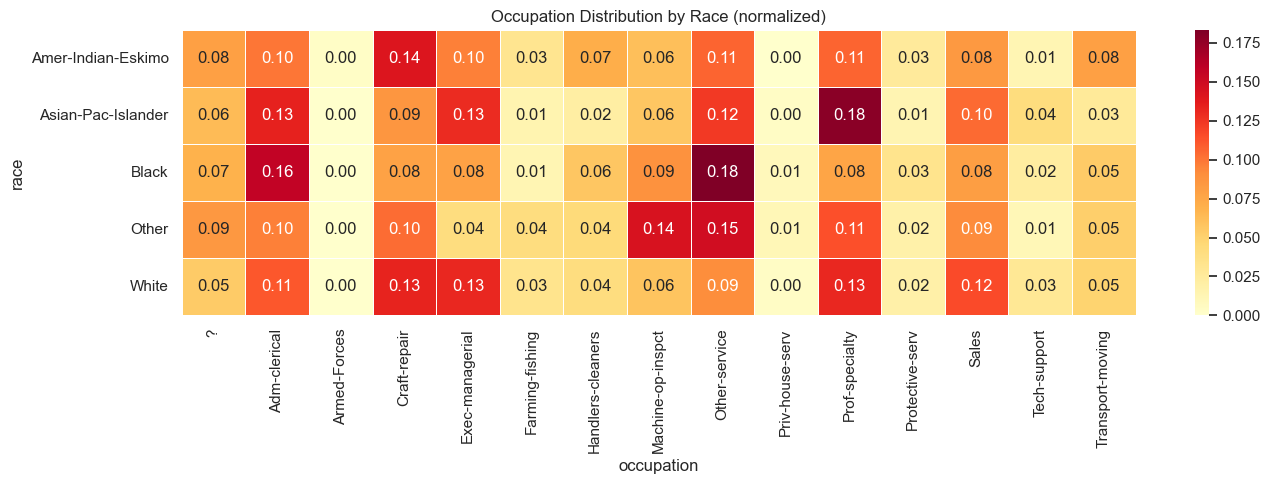

In [21]:
# pivot for heatmap
occ_race = train.groupby("race")["occupation"].value_counts(normalize=True).round(3)
occ_race = occ_race.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
sns.heatmap(
    occ_race,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Occupation Distribution by Race (normalized)")
plt.tight_layout()
plt.savefig("../reports/figures/occupation_by_race.png", dpi=150)
plt.show()

### Observation 7 — Occupation as Race Proxy

The heatmap reveals meaningful differences in occupation distribution across racial groups:

- **Other-service** is heavily skewed: Black (18.3%), Other (14.8%), 
  Amer-Indian-Eskimo (10.6%), Asian (12.3%) vs White (9.1%). 
  Non-white groups are consistently overrepresented in service roles.
- **Prof-specialty and Exec-managerial** tell the opposite story — 
  White and Asian groups show higher concentrations in high-income 
  occupations compared to Black and Amer-Indian-Eskimo groups.
- **Some occupations are distributional neutral** — Transport-moving 
  shows similar proportions across all groups (0.03–0.08), 
  suggesting it is a weaker proxy for race.

This pattern means a model using `occupation` as a feature can implicitly encode race even when `race` is excluded. The high-income 
occupations being concentrated in certain racial groups will likely amplify income prediction bias — a model learns not just occupation,  but the racial composition behind it.

This will be a central finding in the fairness analysis notebook.

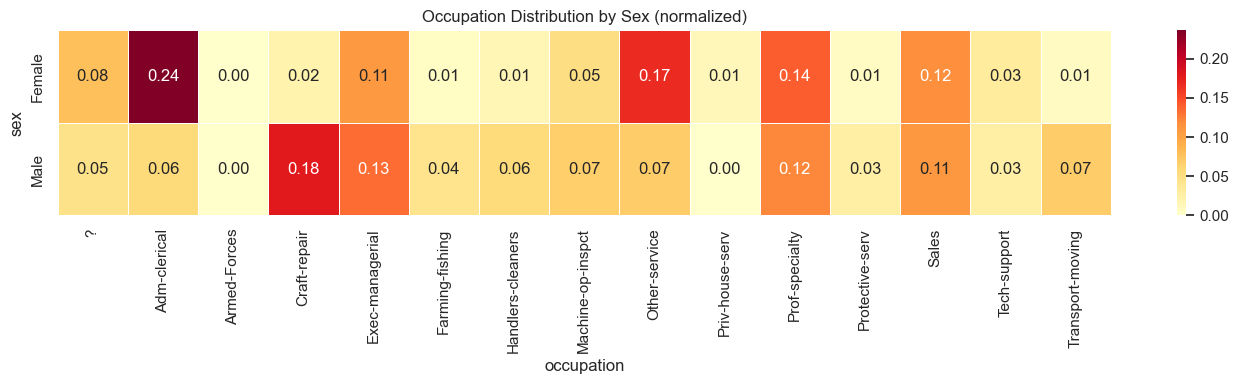

In [22]:
occ_sex = train.groupby("sex")["occupation"].value_counts(normalize=True).round(3)
occ_sex = occ_sex.unstack(fill_value=0)

plt.figure(figsize=(14, 4))
sns.heatmap(
    occ_sex,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Occupation Distribution by Sex (normalized)")
plt.tight_layout()
plt.savefig("../reports/figures/occupation_by_sex.png", dpi=150)
plt.show()

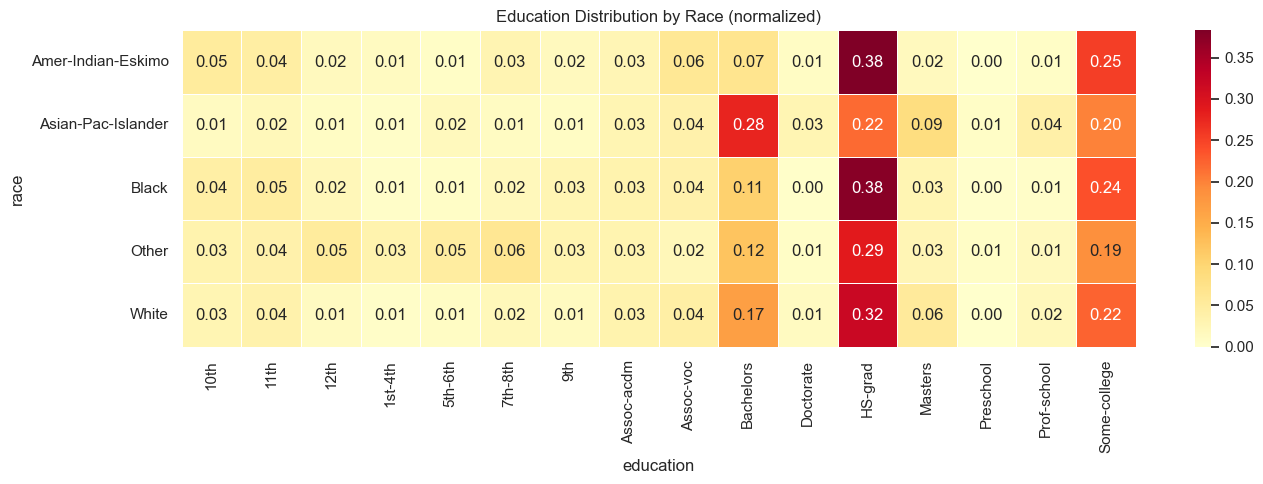

In [23]:
edu_race = train.groupby("race")["education"].value_counts(normalize=True).round(3)
edu_race = edu_race.unstack(fill_value=0)

plt.figure(figsize=(14, 5))
sns.heatmap(
    edu_race,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)
plt.title("Education Distribution by Race (normalized)")
plt.tight_layout()
plt.savefig("../reports/figures/education_by_race.png", dpi=150)
plt.show()

### Observation 8 — Education as Race Proxy

Education distribution reveals meaningful disparities across racial groups:

- **Bachelors:** Asian-Pac-Islander (28%) vs Black (11%) and Amer-Indian-Eskimo (6%) — nearly 5x difference
- **Masters:** Asian-Pac-Islander (9%) vs Black (3%) and Amer-Indian-Eskimo (2%)
- **Doctorate:** Asian-Pac-Islander (4%) vs Black (0%) and Amer-Indian-Eskimo (1%)
- **HS-grad** is the most common education level across all groups — relatively consistent at 32–38%

Higher education credentials are concentrated in White and Asian-Pac-Islander groups. Since education is strongly predictive of income, a model using education as a feature will implicitly encode racial disparities into its predictions — even without using `race` directly.

This is a textbook example of a proxy variable: removing `race` from the feature set does not remove racial bias if correlated features like education and occupation remain.

________________________________________

## 5. Data Audit Verdict

### Summary — What the Data is Telling Us Before Any Modeling

**Data quality is acceptable but requires careful handling:**
- Missing values are encoded as `?` — not standard nulls. 
  A naive null check returns zero and gives false confidence.
- Missingness is structural, not random (MNAR) — concentrated in 
  `workclass`, `occupation`, and `native-country`. Strategy: treat 
  as a meaningful `Unknown` category, do not impute blindly.
- `capital-gain` and `capital-loss` are heavily zero-inflated with 
  a suspicious cap at 99,999 — will require log transformation.
- `fnlwgt` is a census sampling weight — not a predictive feature, 
  will be dropped.
- `education` and `education-num` are redundant — `education-num` 
  will be dropped.

**Three proxy risks identified before modeling:**
1. `occupation` is a strong proxy for both sex and race
2. `education` is a strong proxy for race
3. Removing protected attributes from the feature set does not 
   remove bias — it just makes it harder to detect

**What this means for modeling:**
A model trained on this data without fairness consideration will 
likely learn to discriminate — not because we told it to, but 
because the social inequalities of 1994 are embedded in the 
feature correlations. Accuracy on the test set tells us almost 
nothing about whether the model is fair.

This is why fairness analysis is not an afterthought in this 
project — it is the point.